<a href="https://colab.research.google.com/github/kjian254416-blip/ML300/blob/main/Chapter_4_%EC%83%88%EB%A1%9C_%EC%B6%9C%EC%8B%9C%EB%90%9C_%EA%B2%8C%EC%9E%84%2C_%EC%A0%84%EB%AC%B8%EA%B0%80_%EB%A6%AC%EB%B7%B0_%EB%AF%BF%EA%B3%A0_%EB%B0%94%EB%A1%9C_%EA%B5%AC%EB%A7%A4%ED%95%B4%EB%8F%84_%EB%90%A0%EA%B9%8C%EC%9A%94__%EC%A7%81%EC%A0%91_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A1%9C_%EB%B6%84%EC%84%9D%ED%95%98%EA%B3%A0_%ED%8C%90%EB%8B%A8%ED%95%B4_%EB%B3%B4%EC%9E%90!(%EB%AC%B8%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : 새로 출시된 게임, 전문가 리뷰 믿고 바로 구매해도 될까요? 직접 데이터로 분석하고 판단해 보자!
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 Video Game Sales with Ratings을 사용합니다.
    
    - 다음 1개의 csv 파일을 사용합니다.
    Video_Games_Sales_as_at_22_Dec_2016.csv
    
    - 각 파일의 컬럼은 아래와 같습니다.
    Name: 게임의 이름
    Platform: 게임이 동작하는 콘솔
    Year_of_Release: 발매 년도
    Genre: 게임의 장르
    Publisher: 게임의 유통사
    NA_Sales: 북미 판매량 (Millions)
    EU_Sales: 유럽 연합 판매량 (Millions)
    JP_Sales: 일본 판매량 (Millions)
    Other_Sales: 기타 판매량 (아프리카, 일본 제외 아시아, 호주, EU 제외 유럽, 남미) (Millions)
    Global_Sales: 전국 판매량
    Critic_Score: Metacritic 스태프 점수
    Critic_Count: Critic_Score에 사용된 점수의 수
    User_Score: Metacritic 구독자의 점수
    User_Count: User_Score에 사용된 점수의 수
    Developer: 게임의 개발사
    Rating: ESRB 등급 (19+, 17+, 등등)

    
- 데이터 출처: https://www.kaggle.com/rush4ratio/video-game-sales-with-ratings

## 최종 목표
    - 흥미로운 일상적인 데이터 분석해 보기
    - 데이터 시각화를 통한 인사이트 습득 방법의 이해
    - 학습된 모델로 부터의 인사이트 획득 방법 습득

- 출제자 : 신제용 강사
---

## Step 1. 데이터셋 준비하기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [3]:
import os

In [4]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

os.environ['KAGGLE_USERNAME'] = 'kimjian254416'
os.environ['KAGGLE_KEY'] = '0457ef800614319f99e6b8144bfd741e'

### 문제 2. 데이터 다운로드 및 압축 해제하기


In [5]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기
!rm *.*
!kaggle datasets download -d rush4ratio/video-game-sales-with-ratings
!unzip video-game-sales-with-ratings.zip

rm: cannot remove '*.*': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings
License(s): unknown
100% 476k/476k [00:00<00:00, 116MB/s]

Archive:  video-game-sales-with-ratings.zip
  inflating: Video_Games_Sales_as_at_22_Dec_2016.csv  


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [6]:
df = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')

## Step 2. EDA 및 데이터 기초 통계 분석


### 문제 4. 결손 데이터 데이터프레임에서 제거하기


In [7]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isna().sum()

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [9]:
# dropna() 메소드를 이용하여 결손 데이터가 포함된 row를 제거
df.dropna(inplace=True)

In [10]:
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16667,E.T. The Extra-Terrestrial,GBA,2001.0,Action,NewKidCo,0.01,0.00,0.00,0.00,0.01,46.0,4.0,2.4,21.0,Fluid Studios,E
16677,Mortal Kombat: Deadly Alliance,GBA,2002.0,Fighting,Midway Games,0.01,0.00,0.00,0.00,0.01,81.0,12.0,8.8,9.0,Criterion Games,M
16696,Metal Gear Solid V: Ground Zeroes,PC,2014.0,Action,Konami Digital Entertainment,0.00,0.01,0.00,0.00,0.01,80.0,20.0,7.6,412.0,Kojima Productions,M
16700,Breach,PC,2011.0,Shooter,Destineer,0.01,0.00,0.00,0.00,0.01,61.0,12.0,5.8,43.0,Atomic Games,T


### 문제 5. 수치형 데이터의 히스토그램 확인하기


In [11]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

<Axes: xlabel='Year_of_Release', ylabel='Count'>

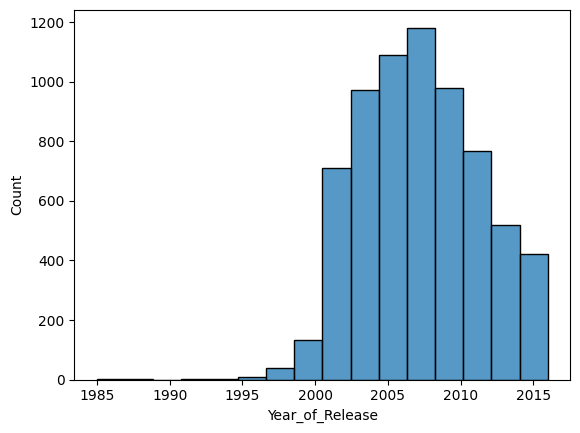

In [12]:
# Seaborn의 histplot()을 이용하여 히스토그램 확인
# 값의 범위가 넓어 히스토그램 분석이 어려울 경우, 아웃라이어를 제거하면서 히스토그램 확인
sns.histplot(x='Year_of_Release',data = df,bins=16)

<Axes: xlabel='Global_Sales', ylabel='Count'>

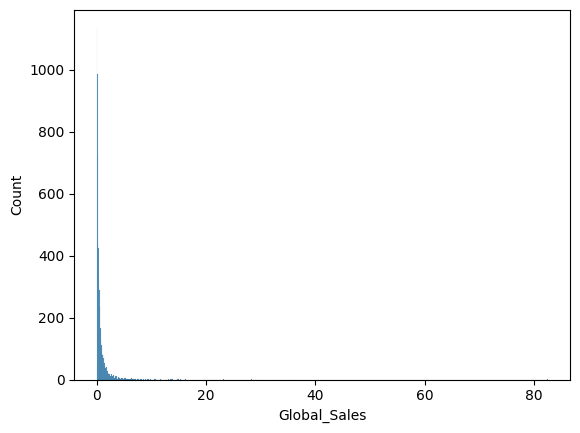

In [13]:
sns.histplot(x='Global_Sales',data=df)

<Axes: xlabel='Global_Sales'>

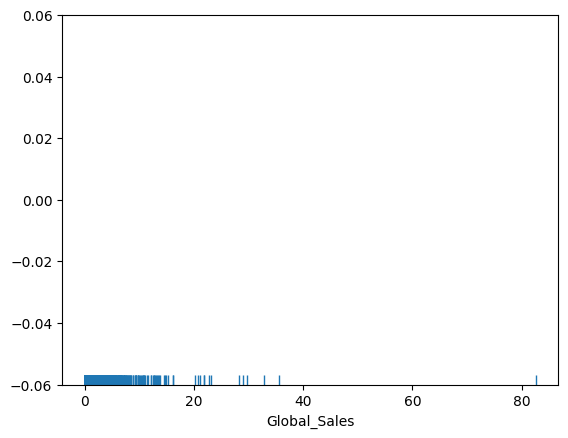

In [14]:
sns.rugplot(x='Global_Sales',data=df)

In [15]:
df[df['Global_Sales']>30]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E


In [16]:
ga = df['Global_Sales'].quantile(0.99)


In [17]:
df = df[df['Global_Sales']<ga]

<Axes: xlabel='Global_Sales', ylabel='Count'>

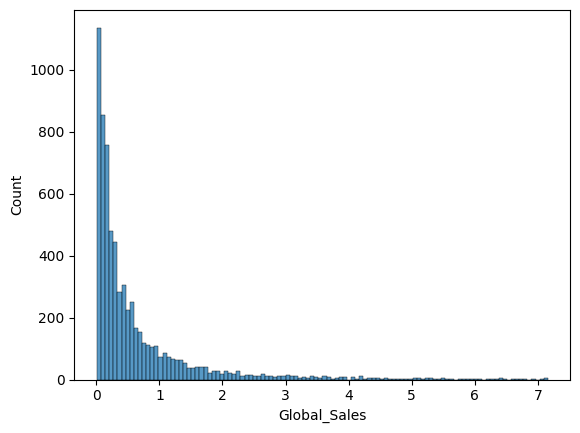

In [19]:
sns.histplot(x='Global_Sales',data=df)

<Axes: xlabel='Global_Sales', ylabel='Count'>

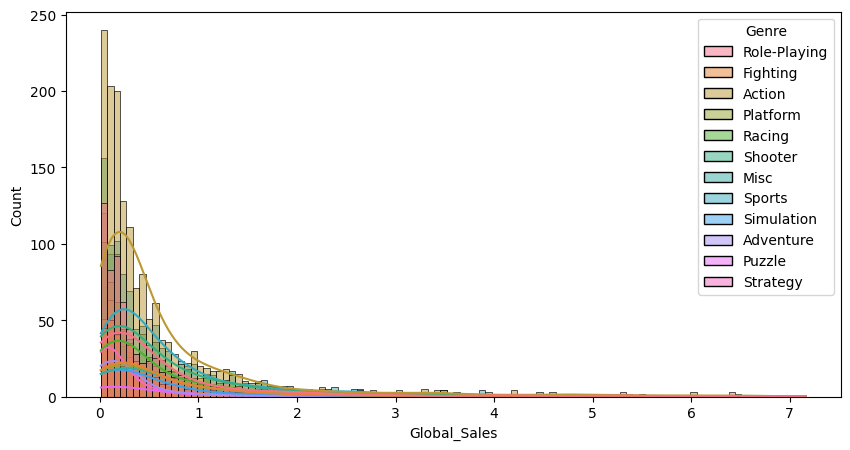

In [21]:
fig = plt.figure(figsize=(10,5))
sns.histplot(x='Global_Sales',hue='Genre',kde=True,data=df)

In [22]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

<Axes: xlabel='Critic_Score', ylabel='Count'>

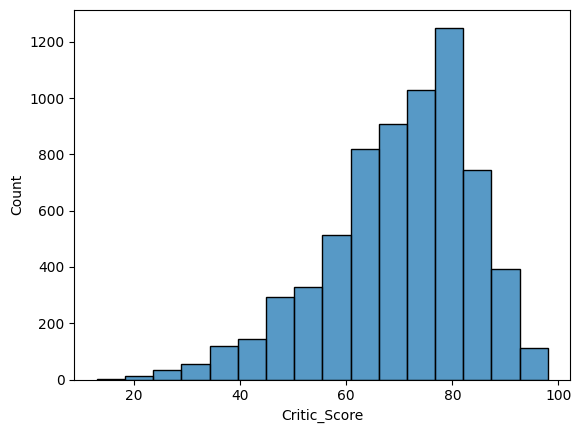

In [23]:
sns.histplot(x='Critic_Score',data=df,bins=16)

<Axes: xlabel='User_Score', ylabel='Count'>

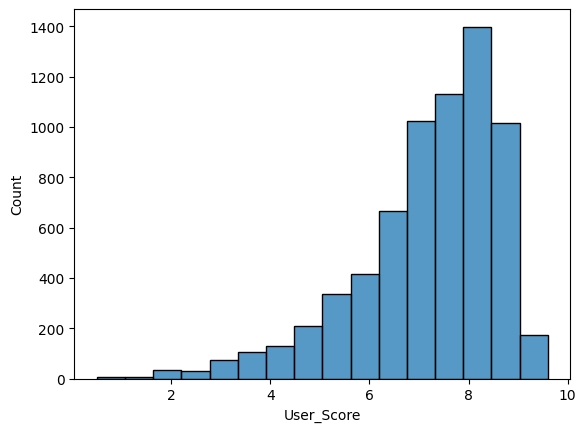

In [26]:
sns.histplot(data=df['User_Score'].apply(float),bins=16)

<Axes: xlabel='Critic_Count', ylabel='Count'>

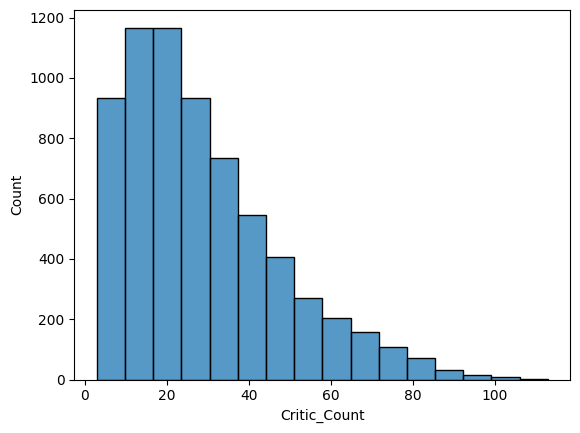

In [27]:
sns.histplot(x='Critic_Count',data=df,bins=16)

<Axes: xlabel='User_Count'>

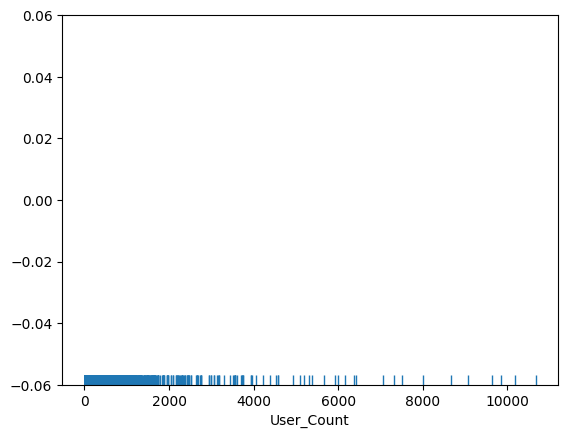

In [28]:
sns.rugplot(x='User_Count',data=df)

In [32]:
uc = df['User_Count'].quantile(0.99)

In [34]:
df = df[df['User_Count']<uc]

<Axes: xlabel='User_Count', ylabel='Count'>

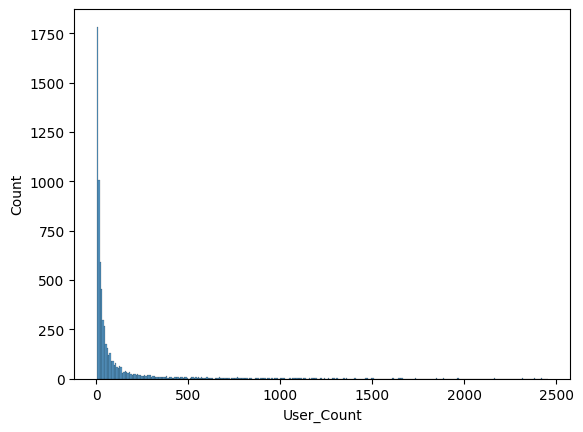

In [35]:
sns.histplot(x='User_Count',data=df)

In [43]:
uc = df['User_Count'].quantile(0.97)
print(uc)

911.5599999999977


<Axes: xlabel='User_Count', ylabel='Count'>

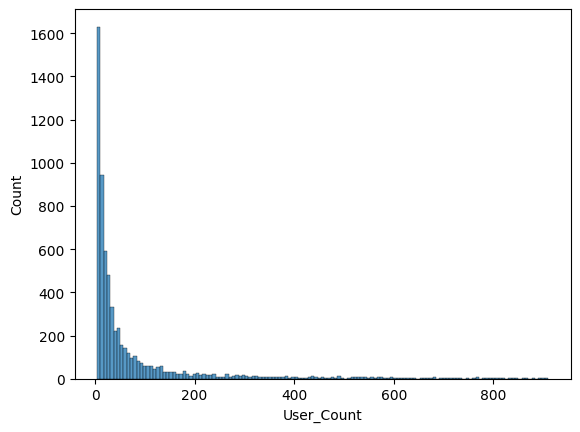

In [44]:
df = df[df['User_Count']<uc]
sns.histplot(x='User_Count',data=df)

### 문제 6. 수치형 데이터와 전국 판매량의 Jointplot 분석하기

In [45]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

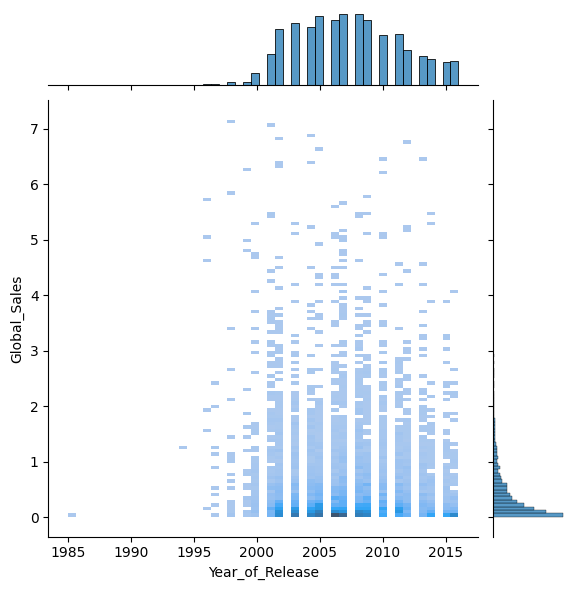

In [48]:
# 수치형 데이터와 전국 판매량의 관계를 Seaborn의 jointplot()으로 시각화/분석
sns.jointplot(x='Year_of_Release',y='Global_Sales',data=df,kind='hist')


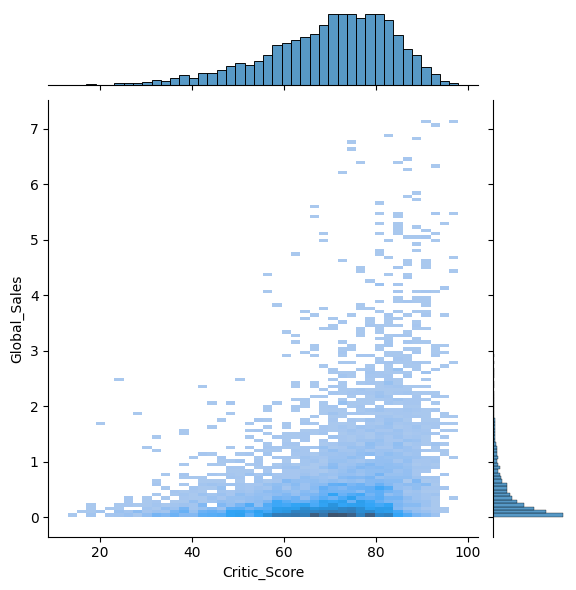

In [50]:
sns.jointplot(x='Critic_Score',y='Global_Sales',data=df,kind='hist')

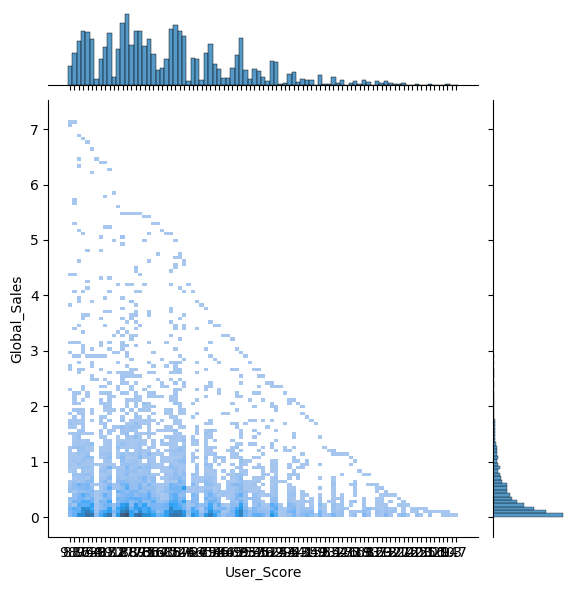

In [51]:
sns.jointplot(x='User_Score',y='Global_Sales',data=df,kind='hist')

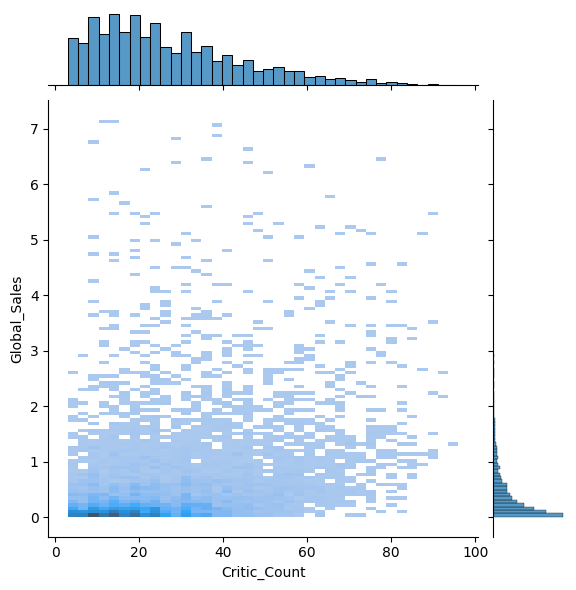

In [52]:
sns.jointplot(x='Critic_Count',y='Global_Sales',data=df,kind='hist')

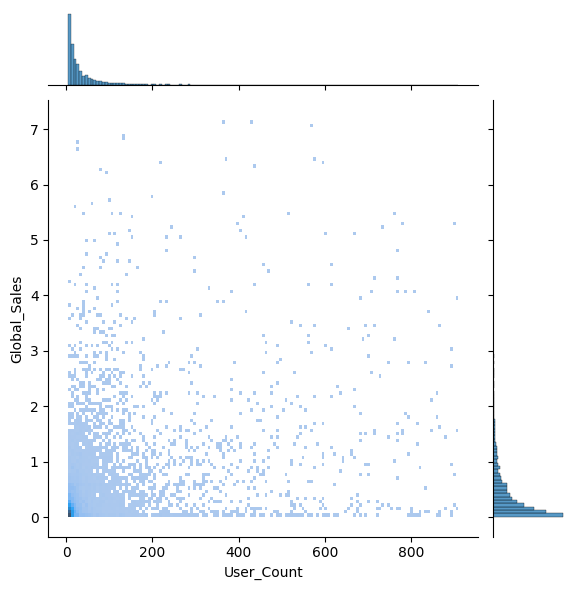

In [53]:
sns.jointplot(x='User_Count',y='Global_Sales',data=df,kind='hist')

### 문제 7. 범주형 데이터의 범주별 전국 판매량의 Boxplot 분석하기

In [54]:
# 범주형 데이터별 전국 판매량의 Boxplot 시각화/분석
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

<Axes: xlabel='Platform', ylabel='Global_Sales'>

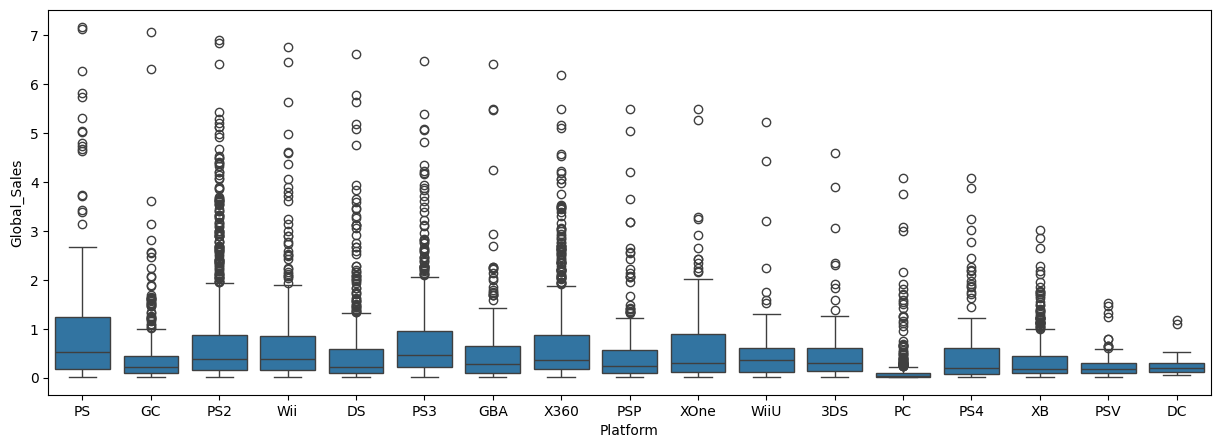

In [57]:
fig = plt.figure(figsize=(15,5))
sns.boxplot(x='Platform',y='Global_Sales',data=df)

<Axes: xlabel='Genre', ylabel='Global_Sales'>

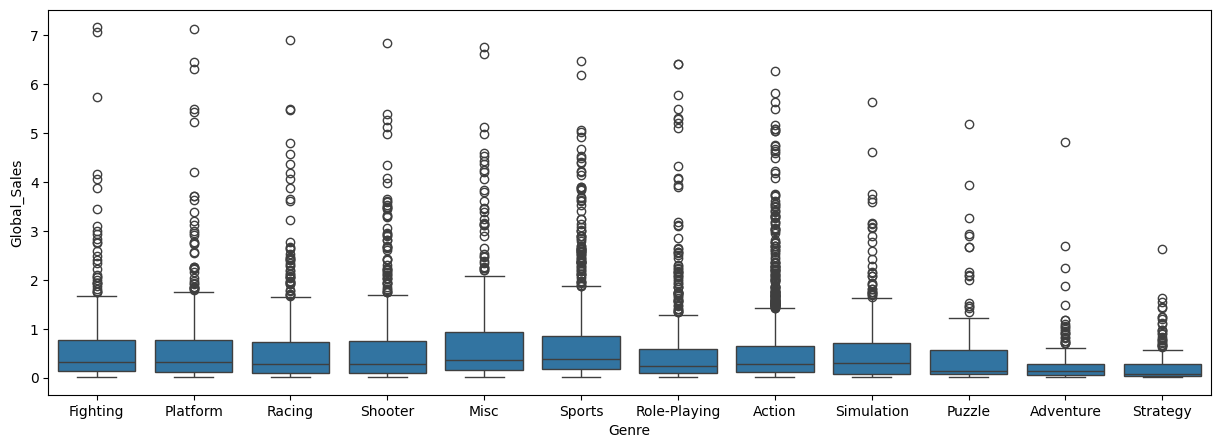

In [58]:
fig = plt.figure(figsize=(15,5))
sns.boxplot(x='Genre',y='Global_Sales',data=df)

<Axes: xlabel='Publisher', ylabel='Global_Sales'>

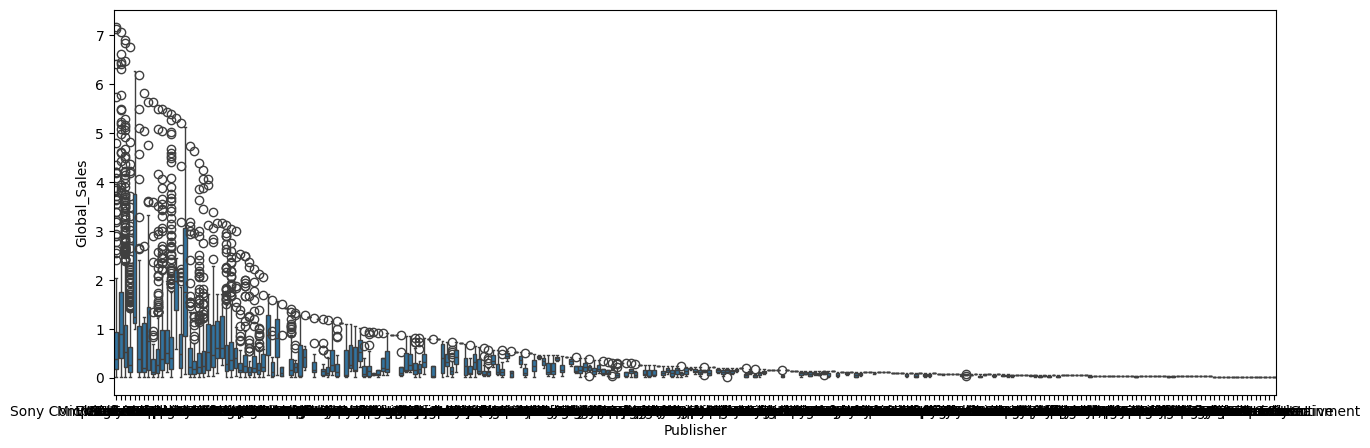

In [59]:
fig = plt.figure(figsize=(15,5))
sns.boxplot(x='Publisher',y='Global_Sales',data=df)

<Axes: xlabel='Developer', ylabel='Global_Sales'>

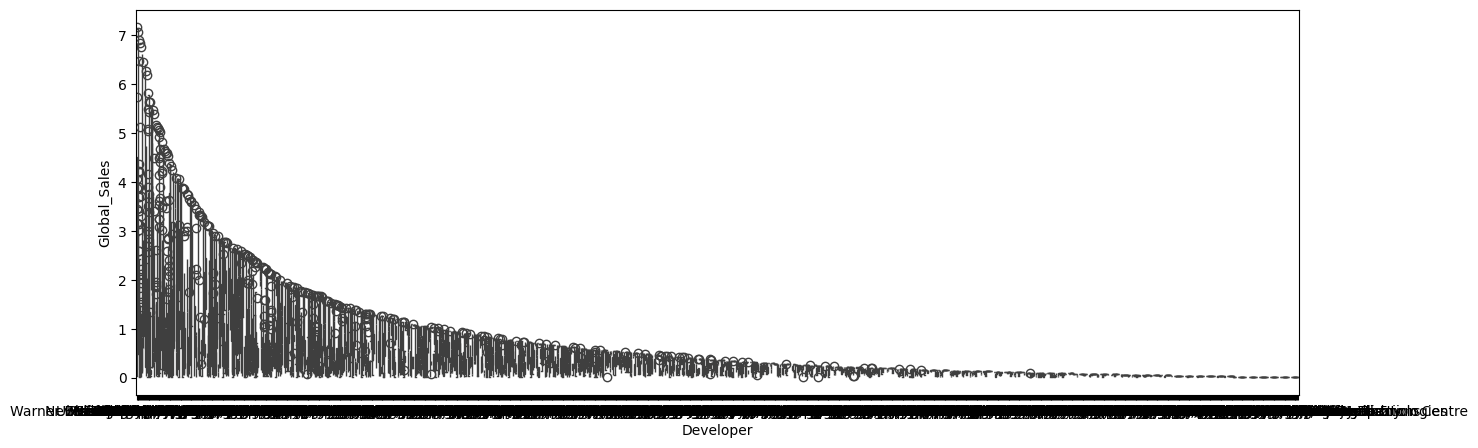

In [60]:
fig = plt.figure(figsize=(15,5))
sns.boxplot(x='Developer',y='Global_Sales',data=df)

### 문제 8. 전문가 평점과 사용자 평점의 차이 분석하기

<Axes: ylabel='Critic_Score'>

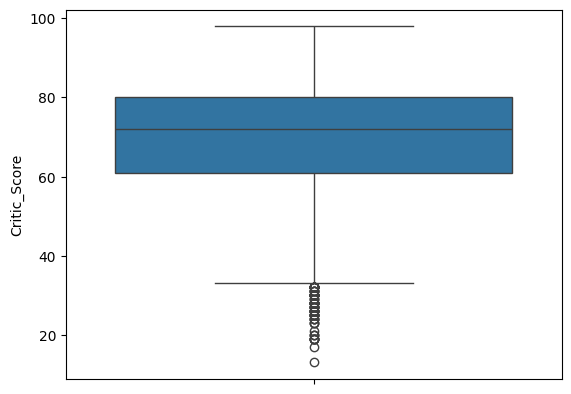

In [61]:
# Seaborn 시각화로 전문가 평점과 사용자 평점의 통계 비교/분석하기
# Hint) 두 값의 범위가 다르므로, 범위를 동일하게 맞추어 비교
# Tip) 별도의 DataFrame을 구성하여 boxplot으로 비교하면 편리함
sns.boxplot(y='Critic_Score',data=df)

<Axes: ylabel='User_Score'>

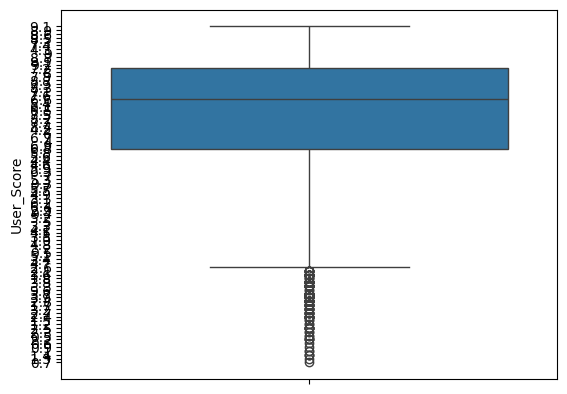

In [62]:
sns.boxplot(y='User_Score',data=df)

In [63]:
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
106,Tekken 3,PS,1998.0,Fighting,Sony Computer Entertainment,3.27,2.22,1.40,0.29,7.16,96.0,15.0,9.1,367.0,Namco,T
109,Crash Bandicoot 3: Warped,PS,1998.0,Platform,Sony Computer Entertainment,3.68,1.75,1.42,0.28,7.13,91.0,12.0,8.9,432.0,Naughty Dog,E
111,Super Smash Bros. Melee,GC,2001.0,Fighting,Nintendo,4.41,1.04,1.39,0.22,7.07,92.0,38.0,9.1,568.0,HAL Labs,T
113,Need for Speed Underground 2,PS2,2004.0,Racing,Electronic Arts,2.71,3.02,0.08,1.09,6.90,82.0,39.0,8.6,132.0,EA Canada,E
114,Medal of Honor: Frontline,PS2,2002.0,Shooter,Electronic Arts,2.93,2.75,0.17,0.99,6.83,88.0,29.0,8.5,135.0,EA LA,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16667,E.T. The Extra-Terrestrial,GBA,2001.0,Action,NewKidCo,0.01,0.00,0.00,0.00,0.01,46.0,4.0,2.4,21.0,Fluid Studios,E
16677,Mortal Kombat: Deadly Alliance,GBA,2002.0,Fighting,Midway Games,0.01,0.00,0.00,0.00,0.01,81.0,12.0,8.8,9.0,Criterion Games,M
16696,Metal Gear Solid V: Ground Zeroes,PC,2014.0,Action,Konami Digital Entertainment,0.00,0.01,0.00,0.00,0.01,80.0,20.0,7.6,412.0,Kojima Productions,M
16700,Breach,PC,2011.0,Shooter,Destineer,0.01,0.00,0.00,0.00,0.01,61.0,12.0,5.8,43.0,Atomic Games,T


In [67]:
critic_score = df[['Critic_Score']].copy()
critic_score.rename({'Critic_Score':'Score'},axis=1,inplace=True)
critic_score['ScoreBy'] = 'Critics'

In [79]:
user_score = df[['User_Score']].astype(float).copy() * 10
user_score.rename({'User_Score':'Score'},axis=1,inplace=True)
user_score['ScoreBy'] = 'Users'

In [86]:
scores = pd.concat([critic_score,user_score])
scores

,Score,ScoreBy
106,96.0,Critics
109,91.0,Critics
111,92.0,Critics
113,82.0,Critics
114,88.0,Critics
...,...,...
16667,24.0,Users
16677,88.0,Users
16696,76.0,Users
16700,58.0,Users


<Axes: xlabel='ScoreBy', ylabel='Score'>

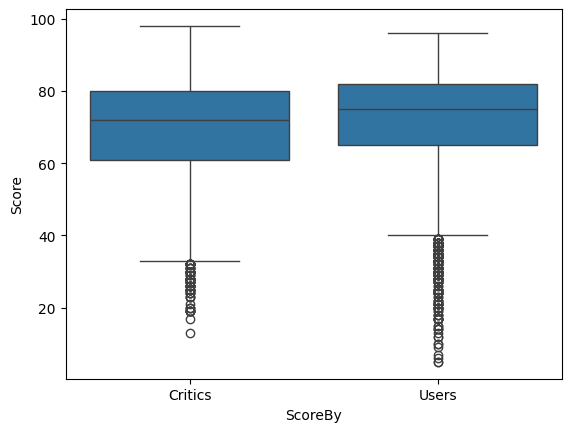

In [87]:
sns.boxplot(x='ScoreBy',y='Score',data=scores)

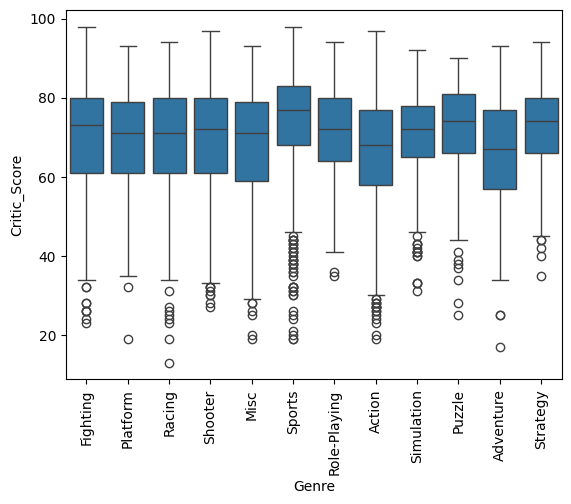

In [82]:
sns.boxplot(x='Genre',y='Critic_Score',data=df)
plt.xticks(rotation=90)
plt.show()

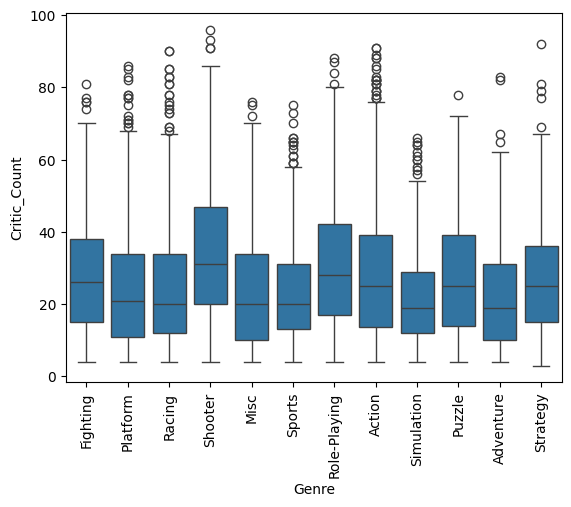

In [84]:
sns.boxplot(x='Genre',y='Critic_Count',data=df)
plt.xticks(rotation=90)
plt.show()

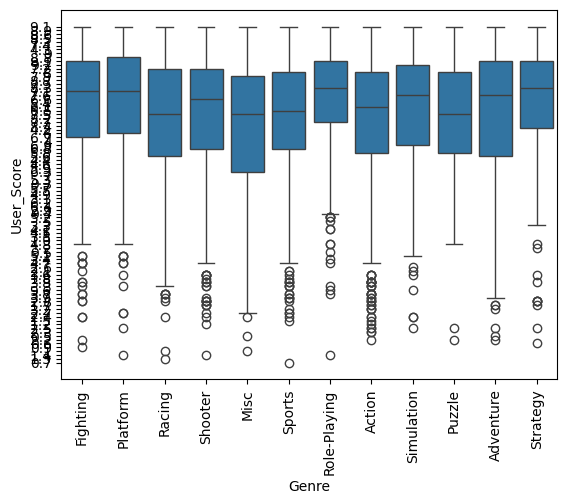

In [83]:
sns.boxplot(x='Genre',y='User_Score',data=df)
plt.xticks(rotation=90)
plt.show()

### 문제 9. 수치형 데이터간의 상관성 시각화하기

<Axes: >

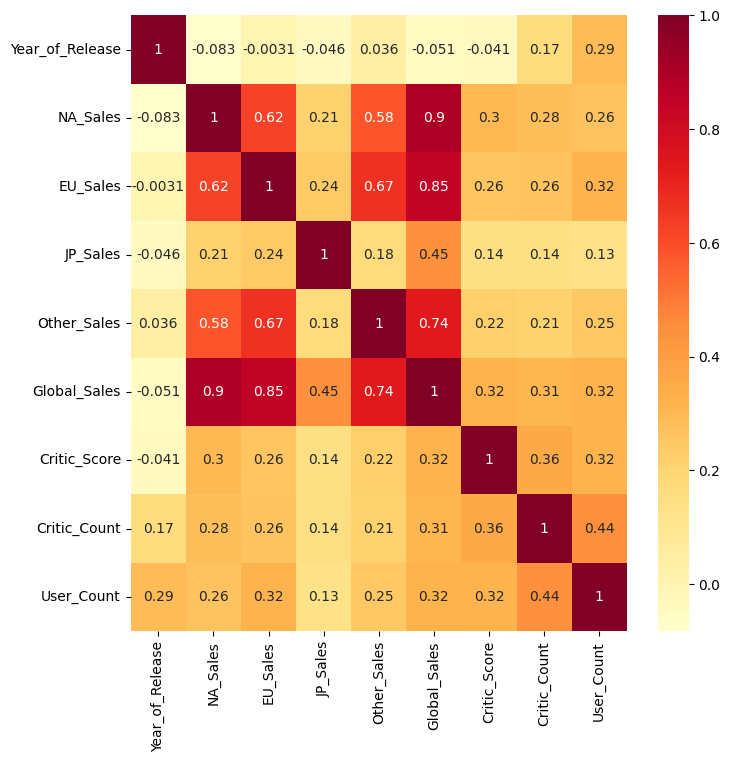

In [88]:
# Correlation Heatmap 시각화하기
fig = plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='YlOrRd')

## Step 3. 모델 학습을 위한 데이터 전처리

### 문제 10. 범주형 데이터에서 소수 범주를 others로 대체하기

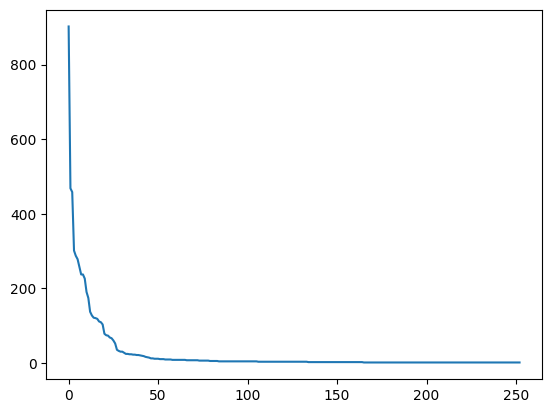

In [89]:
# 범주형 데이터 중 범주가 너무 적은 경우 others 범주로 대체하기
# Hint) value_counts()를 이용하여 범주별 개수를 확인

pb = df['Publisher'].value_counts()
plt.plot(range(len(pb)),pb)

In [90]:
df['Publisher'] = df['Publisher'].apply(lambda s: s if s not in  pb[20:] else 'others')

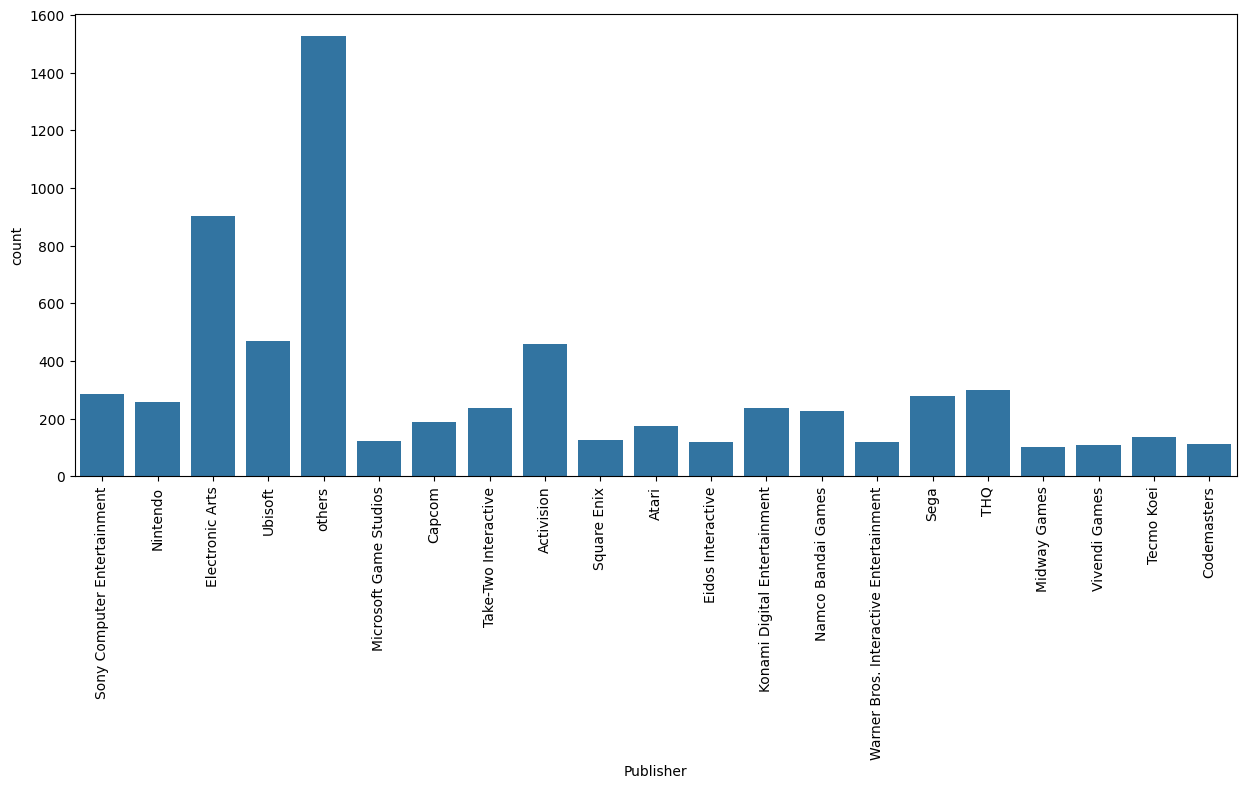

In [92]:
fig = plt.figure(figsize=(15,6))
sns.countplot(x='Publisher',data=df)
plt.xticks(rotation=90)
plt.show()

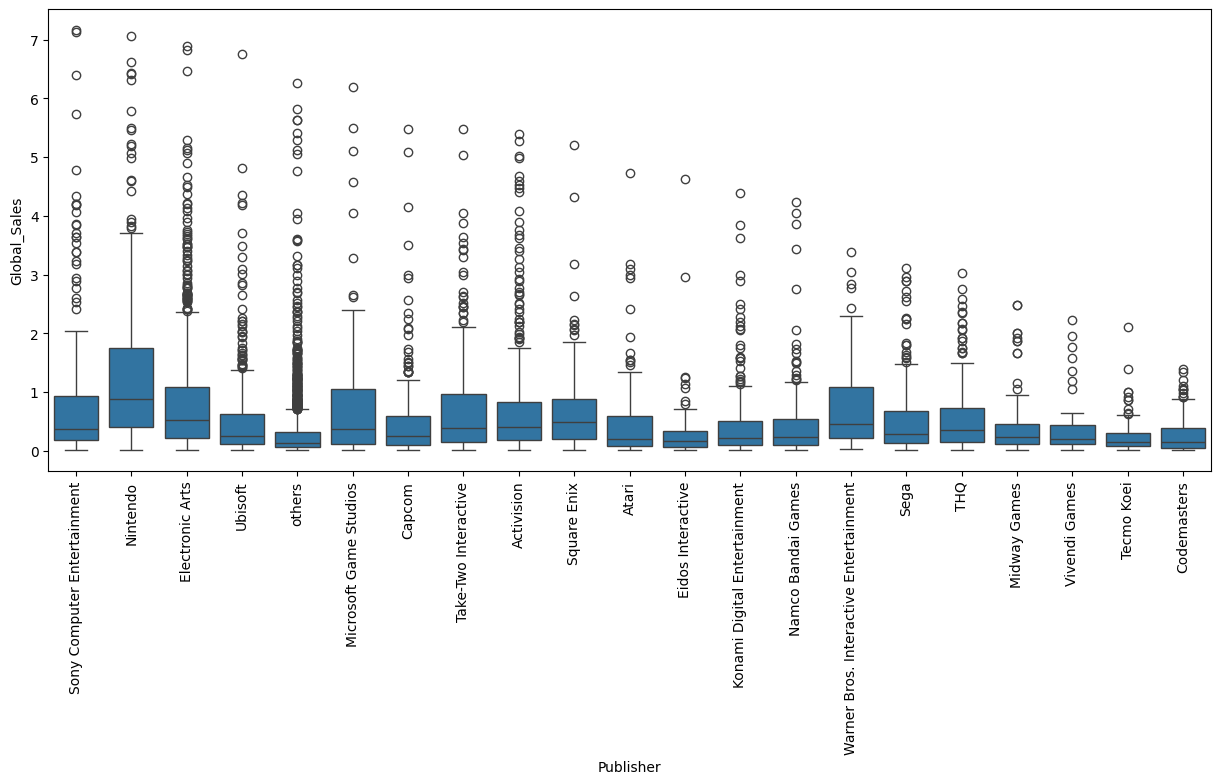

In [95]:
fig = plt.figure(figsize=(15,6))
sns.boxplot(x='Publisher',y='Global_Sales',data=df)
plt.xticks(rotation=90)
plt.show()

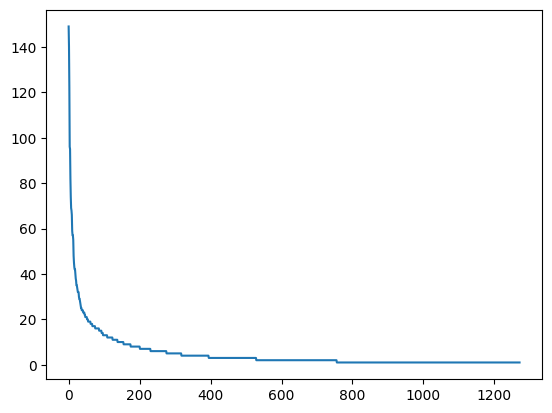

In [97]:
dev = df['Developer'].value_counts()
plt.plot(range(len(dev)),dev)

In [100]:
df['Developer'] = df['Developer'].apply(lambda s: s if s not in  dev[20:] else 'others')

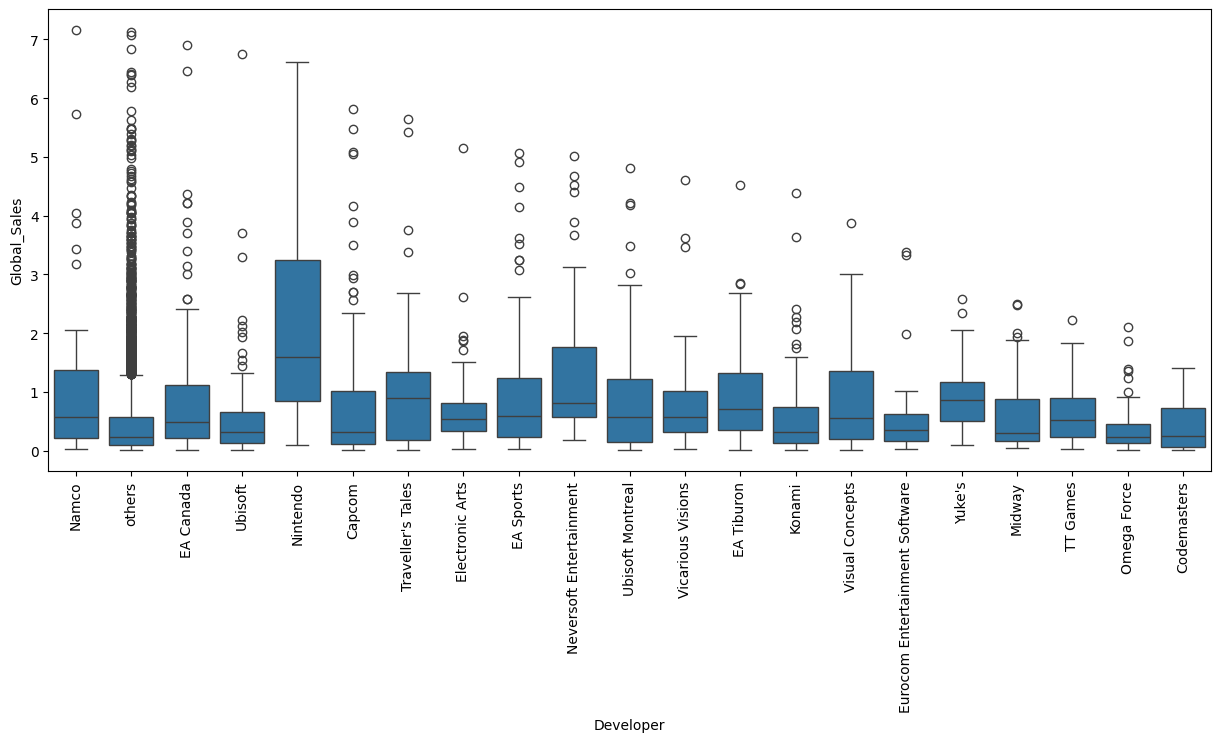

In [101]:
fig = plt.figure(figsize=(15,6))
sns.boxplot(x='Developer',y='Global_Sales',data=df)
plt.xticks(rotation=90)
plt.show()

### 문제 11. get_dummies를 이용한 범주형 데이터 전처리


In [102]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [103]:
X_cat = df[[ 'Platform', 'Genre', 'Publisher'] ]
X_cat = pd.get_dummies(X_cat,drop_first=True)
X_cat

,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,...,Publisher_Sega,Publisher_Sony Computer Entertainment,Publisher_Square Enix,Publisher_THQ,Publisher_Take-Two Interactive,Publisher_Tecmo Koei,Publisher_Ubisoft,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,Publisher_others
106,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
109,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
111,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
113,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
114,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16667,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
16677,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16696,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16700,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## Step 4. 전국 판매량 Regression 모델 학습하기

### 문제 12. 전국 판매량 추정을 위한 입출력 데이터 구성하기


In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [106]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [108]:
# 전국 판매량 추정을 위해 적절한 입력과 출력 컬럼 선정
# 수치형 데이터는 StandardScaler를 이용해 표준화
X_num = df[['Year_of_Release','Critic_Score','Critic_Count']]
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(X_scaled,index = X_num.index,columns=X_num.columns)
X = pd.concat([X_scaled,X_cat],axis=1)
y =df['Global_Sales']




In [109]:
X.head()

,Year_of_Release,Critic_Score,Critic_Count,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,Platform_PS2,...,Publisher_Sega,Publisher_Sony Computer Entertainment,Publisher_Square Enix,Publisher_THQ,Publisher_Take-Two Interactive,Publisher_Tecmo Koei,Publisher_Ubisoft,Publisher_Vivendi Games,Publisher_Warner Bros. Interactive Entertainment,Publisher_others
106,-2.237912,1.944152,-0.704478,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
109,-2.237912,1.577371,-0.874440,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
111,-1.514757,1.650727,0.598567,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
113,-0.791602,0.917163,0.655221,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
114,-1.273706,1.357302,0.088680,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [110]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

### 문제 13. XGBoost 모델 생성/학습하기

In [111]:
from xgboost import XGBRegressor

In [113]:
# XGBRegressor 모델 생성/학습
model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)




XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### 문제 14. Linear Regression 모델 생성/학습하기

In [114]:
from sklearn.linear_model import LinearRegression

In [115]:
# LinearRegression 모델 생성/학습
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)




LinearRegression()

### 문제 15. 모델 학습 결과 평가하기

In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

In [118]:
# Predict를 수행하고 mean_absolute_error, rmse 결과 출력하기
pred_xgb = model_xgb.predict(X_test)
pred_lr = model_lr.predict(X_test)

print('XGB MAE:',mean_absolute_error(y_test,pred_xgb))
print('XGB RMSE:',sqrt(mean_squared_error(y_test,pred_xgb)))
print('LR MAE:',mean_absolute_error(y_test,pred_lr))
print('LR RMSE:',sqrt(mean_squared_error(y_test,pred_lr)))

XGB MAE: 0.4148630319698899
XGB RMSE: 0.7330262667325831
LR MAE: 0.4435623723861832
LR RMSE: 0.7033240396642875


### 문제 16. 실제 값과 추측 값의 Scatter plot 시각화하기


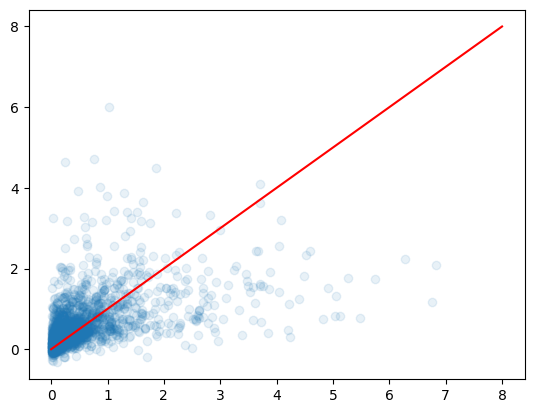

In [122]:
# y_test vs. pred Scatter 플랏으로 시각적으로 분석하기
plt.scatter(y_test,pred_xgb,alpha=0.1)
plt.plot([0,8],[0,8],'r-')

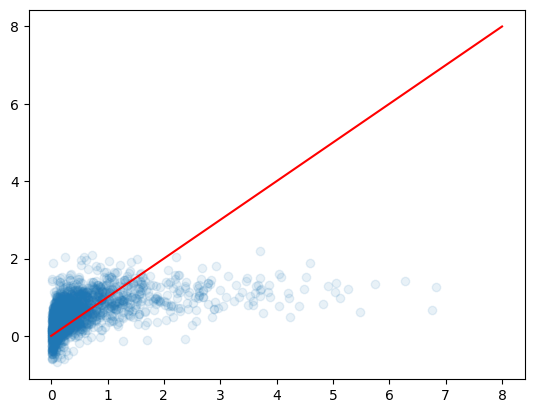

In [123]:
plt.scatter(y_test,pred_lr,alpha=0.1)
plt.plot([0,8],[0,8],'r-')

### 문제 17. XGBoost 모델의 Feature Importance 시각화하기

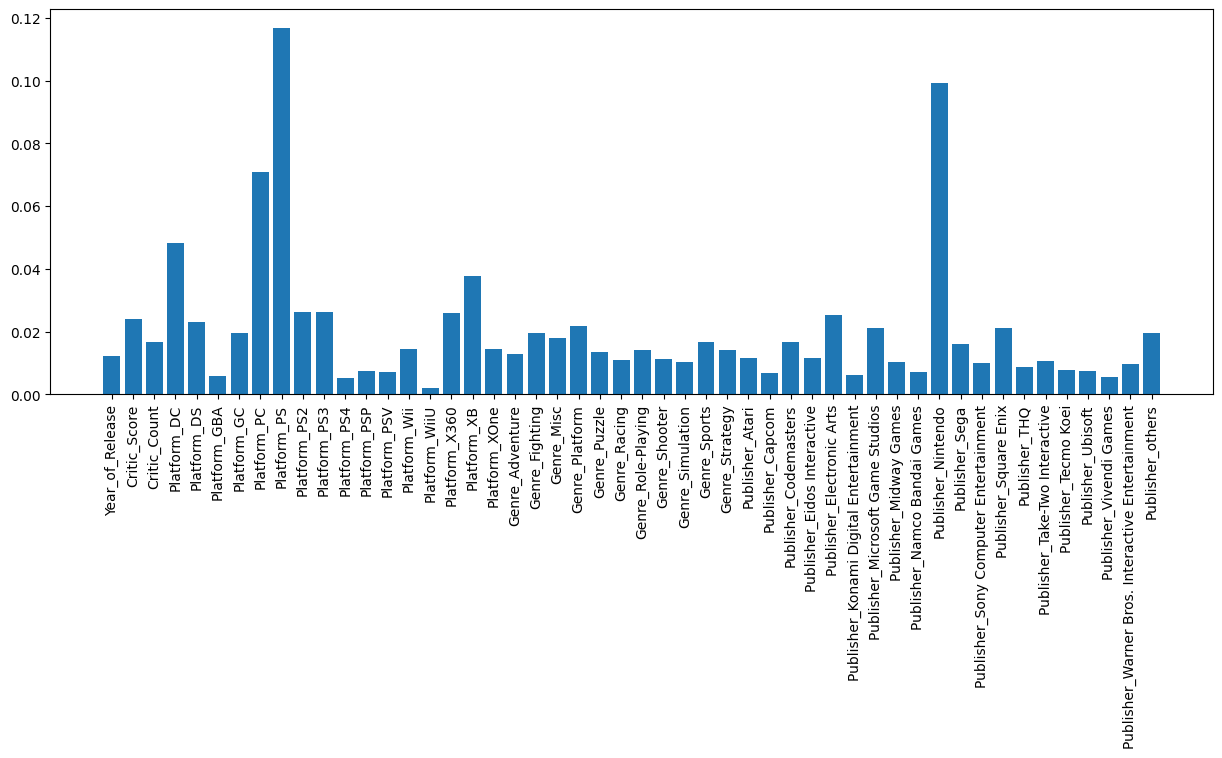

In [124]:
fig = plt.figure(figsize=(15,5))
plt.bar(X.columns,model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()

## Step 5. 유저 평점 Regression 모델 학습하기

### 문제 18. 유저 평점 추정을 위한 입출력 데이터 구성하기


In [125]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [127]:
# 유저 평점 추정을 위해 적절한 입력과 출력 컬럼 선정
# 수치형 데이터는 StandardScaler를 이용해 표준화

X_num = df[['Year_of_Release','Critic_Score','Critic_Count']]
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(X_scaled,index = X_num.index,columns=X_num.columns)

X = pd.concat([X_scaled,X_cat],axis=1)
y =df['User_Score']

In [128]:
#train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

### 문제 19. XGBoost 모델 생성/학습하기

In [129]:
# XGBRegressor 모델 생성/학습
model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)




XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### 문제 20. Linear Regression 모델 생성/학습하기

In [130]:
# LinearRegression 모델 생성/학습
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)



LinearRegression()

### 문제 21. 모델 학습 결과 평가하기

In [131]:
# Predict를 수행하고 mean_absolute_error, rmse 결과 출력하기
pred_xgb = model_xgb.predict(X_test)
pred_lr = model_lr.predict(X_test)

print('XGB MAE:',mean_absolute_error(y_test,pred_xgb))
print('XGB RMSE:',sqrt(mean_squared_error(y_test,pred_xgb)))
print('LR MAE:',mean_absolute_error(y_test,pred_lr))
print('LR RMSE:',sqrt(mean_squared_error(y_test,pred_lr)))

XGB MAE: 0.7835894227027893
XGB RMSE: 1.0764550807385223
LR MAE: 0.779957137091311
LR RMSE: 1.0532062590705695


### 문제 22. 실제 값과 추측 값의 Scatter plot 시각화하기


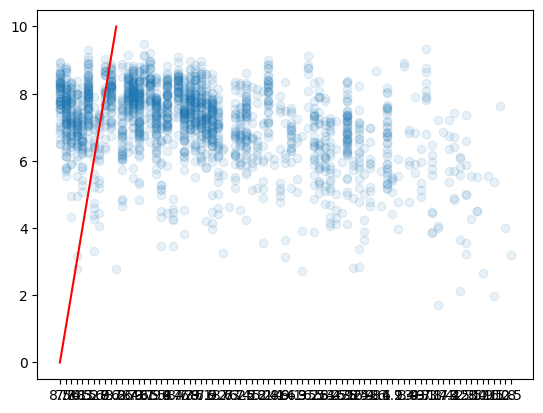

In [132]:
# y_test vs. pred Scatter 플랏으로 시각적으로 분석하기

plt.scatter(y_test,pred_xgb,alpha=0.1)
plt.plot([0,10],[0,10],'r-')

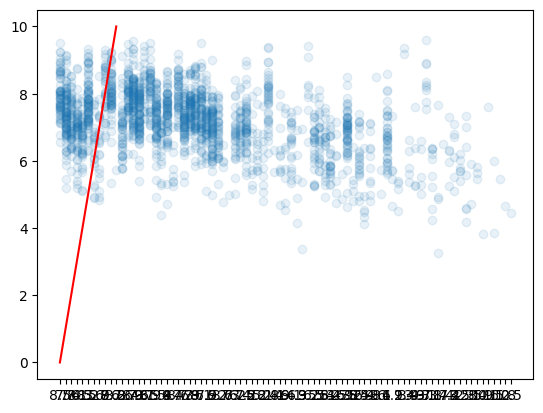

In [133]:
plt.scatter(y_test,pred_lr,alpha=0.1)
plt.plot([0,10],[0,10],'r-')

### 문제 23. XGBoost 모델의 Feature Importance 시각화하기

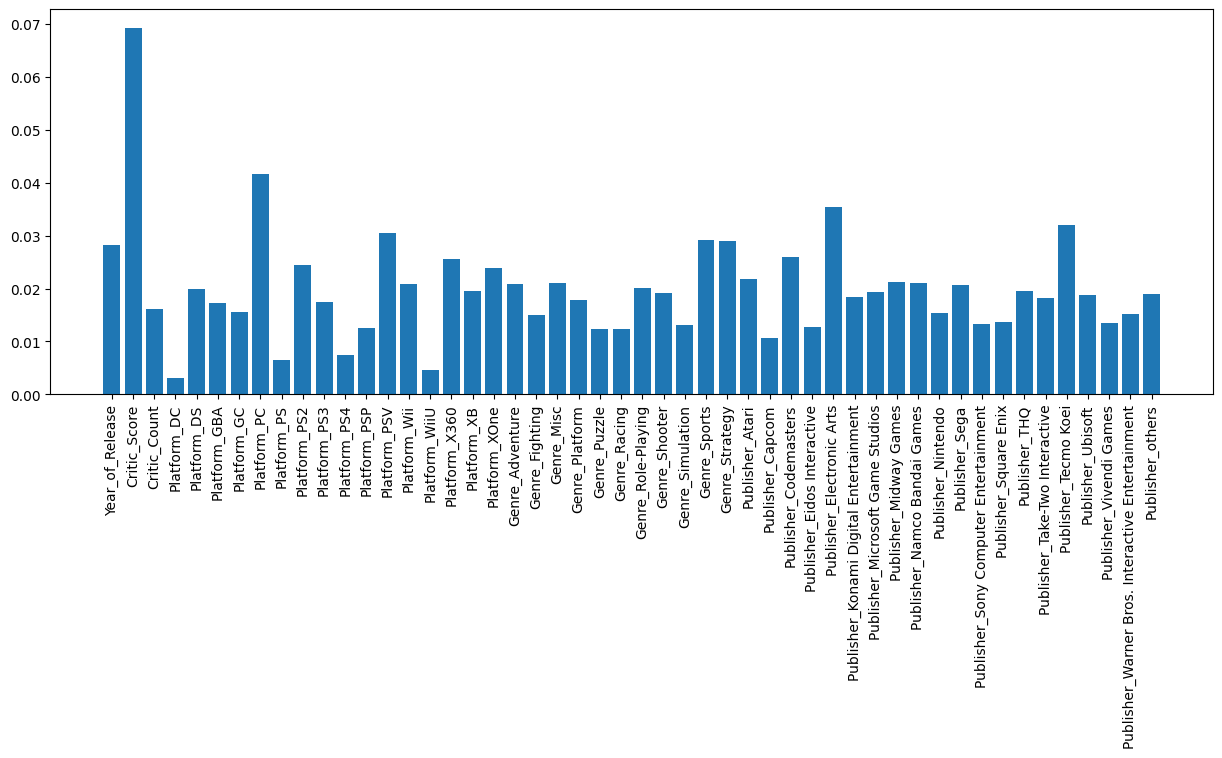

In [134]:
fig = plt.figure(figsize=(15,5))
plt.bar(X.columns,model_xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()